# <span style="color:purple; font-weight:bold; text-decoration:underline;"> Maps of Burden Climatologies

### <span style="color:purple"> Imports

In [1]:
# Third-party libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from cartopy import crs as ccrs, feature as cfeature

# Custom utilities
import utils
from utils.load_variable import load_variables_for_all_years

### <span style="color:purple"> Loading SO4 Burden

In [2]:
BURDENSO4   = load_variables_for_all_years('h3', 'BURDENSO4dn')   # kg m-2

In [3]:
Burden_SO4_2006 = BURDENSO4['2006'].groupby('time.month').mean(dim=['time']).roll(month=-1)
Burden_SO4_2006_AMJ = np.log10(Burden_SO4_2006.sel(month=[4,5,6]).mean(dim='month'))
Burden_SO4_2006_NDJ = np.log10(Burden_SO4_2006.sel(month=[11,12,1]).mean(dim='month'))

### <span style="color:purple"> Calculating Monthly Climatologies

In [4]:
BURDENSO4_monthly = (np.log10(BURDENSO4['2006']) - np.log10(BURDENSO4['1970'])).groupby('time.month').mean().roll(month=-1)

### <span style="color:purple"> Grouping Monthly Climatologies to Max, Min, and Difference in Months

In [5]:
def get_months(dataset, month_list_a, month_list_b):
    dataset_a = dataset.sel(month=month_list_a).mean('month')
    dataset_b = dataset.sel(month=month_list_b).mean('month')
    diff = dataset_a - dataset_b
    return dataset_a, dataset_b, diff


peak_months = [4, 5, 6]
min_months = [11, 12, 1]

BURDENSO4_max, BURDENSO4_min, diff_BURDENSO4 = get_months(BURDENSO4_monthly, peak_months, min_months)

### <span style="color:purple"> Plotting  Monthly Climatologies of Max, Min, and Difference in Months

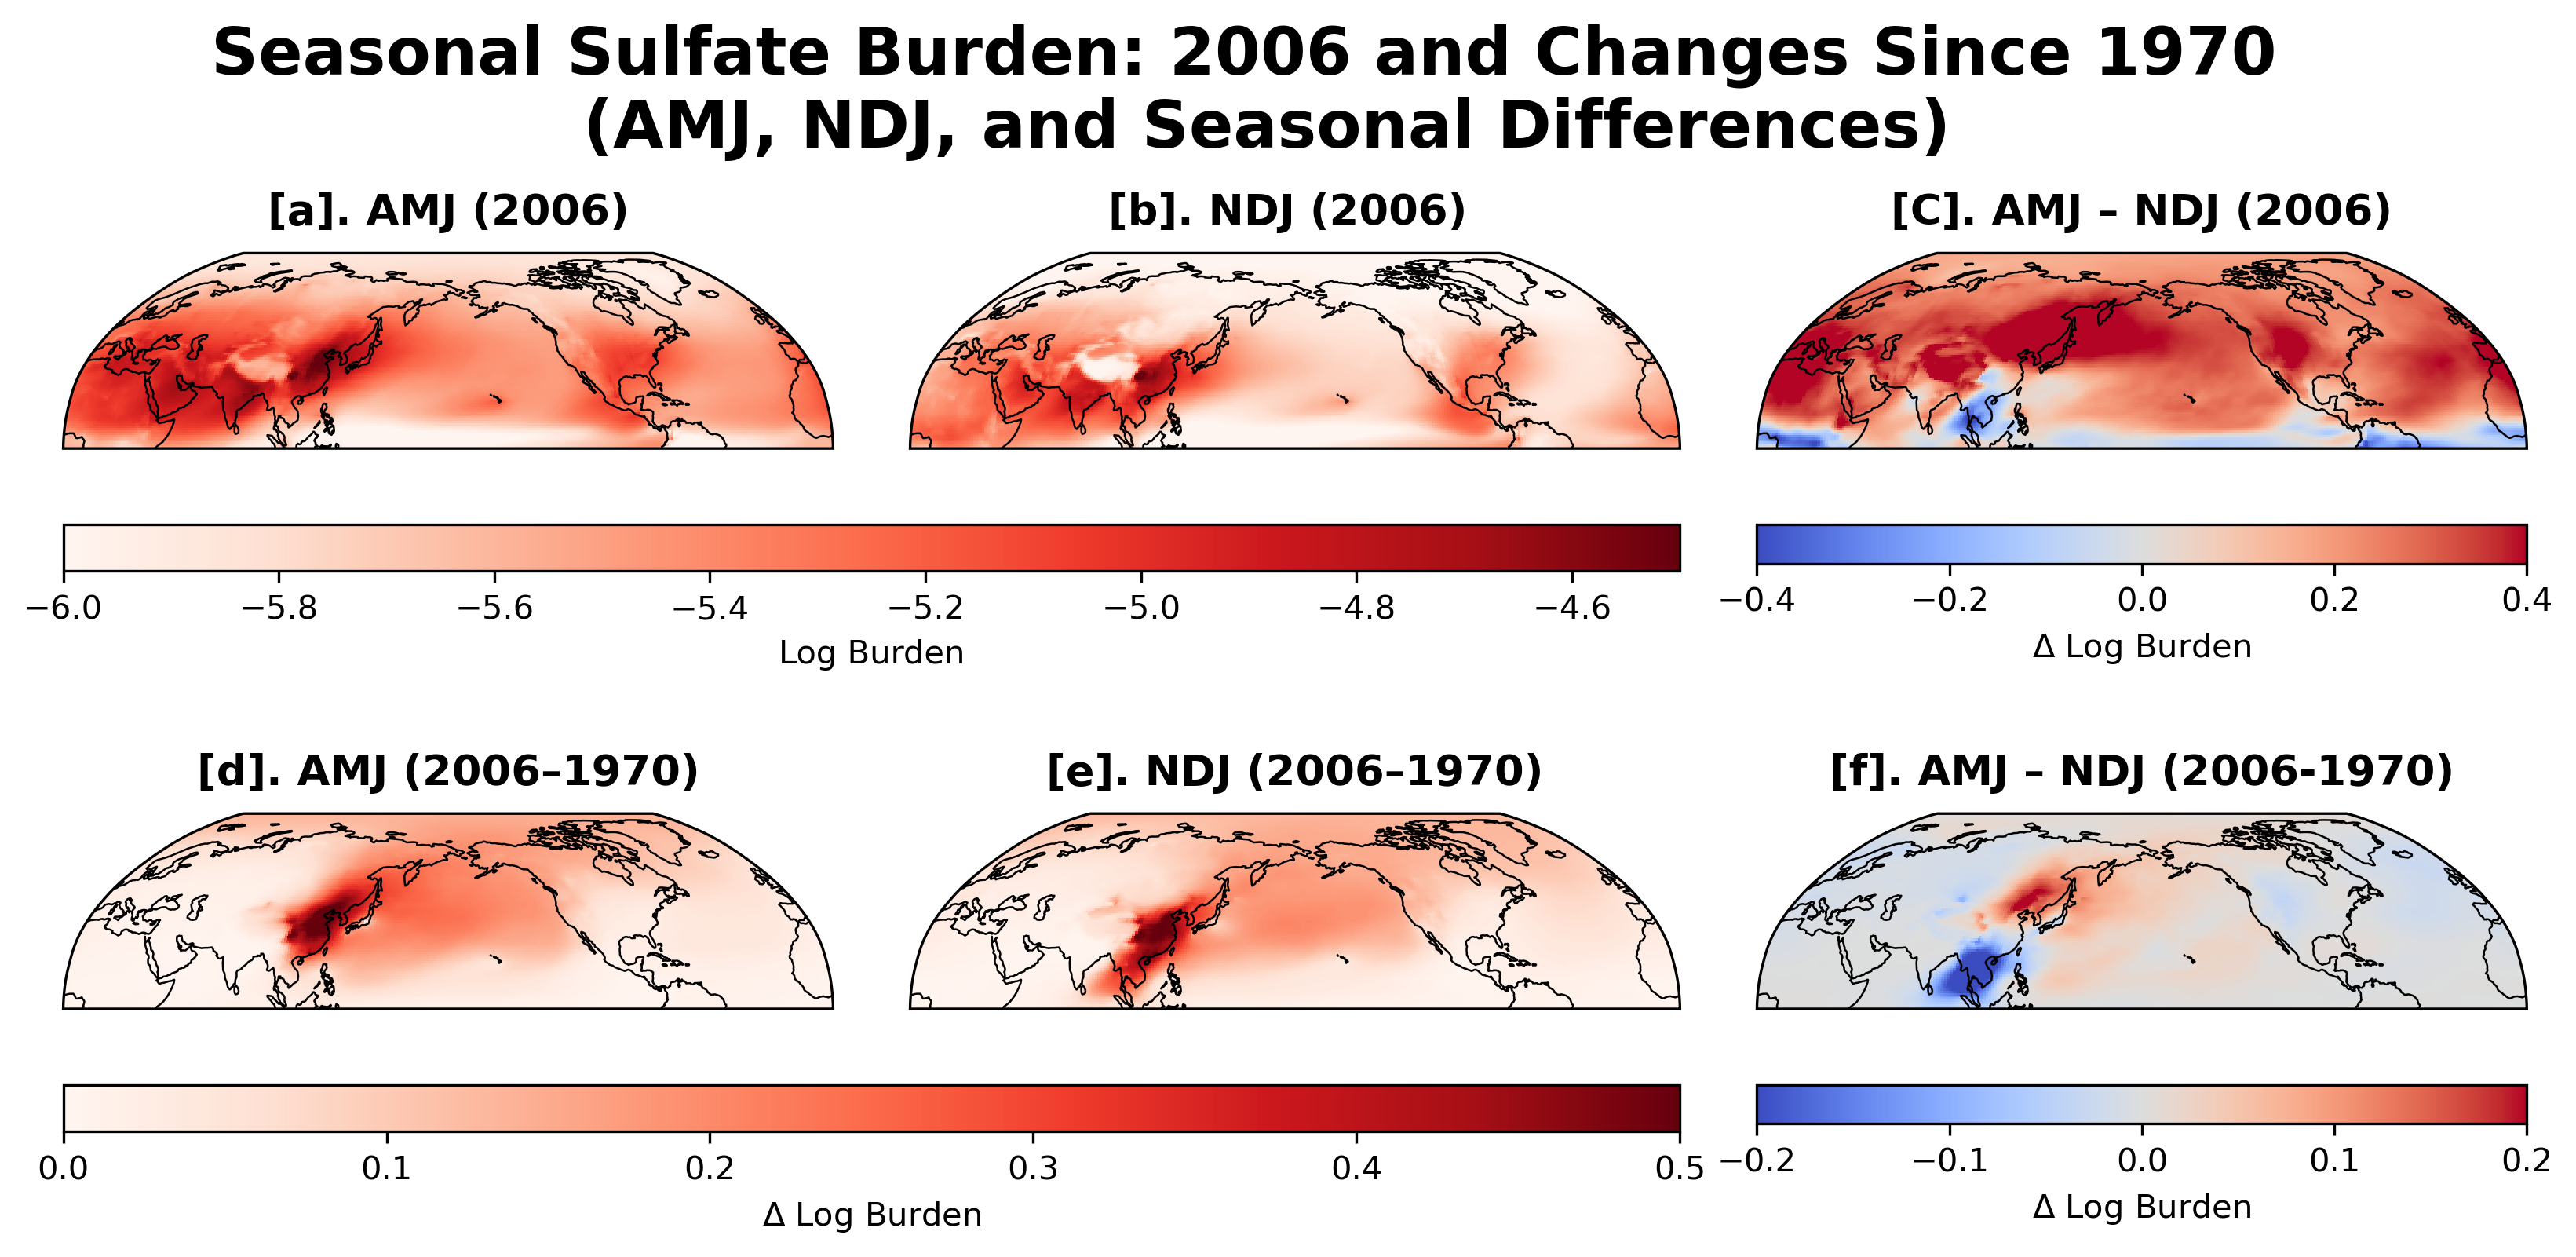

In [6]:
lon = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/dimension_files/model_dims/lon.nc')
lat = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/dimension_files/model_dims/lat.nc')

fig, axs = plt.subplots(2, 3, figsize=(13.5, 5.75), subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}, dpi=300)
axs = axs.flatten()

# Plotting
m3 = axs[0].pcolormesh(lon, lat, Burden_SO4_2006_AMJ, transform=ccrs.PlateCarree(), vmin=-6, vmax=-4.5, cmap='Reds')
m4 = axs[1].pcolormesh(lon, lat, Burden_SO4_2006_NDJ, transform=ccrs.PlateCarree(), vmin=-6, vmax=-4.5, cmap='Reds')
m5 = axs[2].pcolormesh(lon, lat, (Burden_SO4_2006_AMJ-Burden_SO4_2006_NDJ), transform=ccrs.PlateCarree(), vmin=-0.4, vmax=0.4, cmap='coolwarm')

m6 = axs[3].pcolormesh(lon, lat, BURDENSO4_max, transform=ccrs.PlateCarree(), vmin=0, vmax=0.5, cmap='Reds')
m7 = axs[4].pcolormesh(lon, lat, BURDENSO4_min, transform=ccrs.PlateCarree(), vmin=0, vmax=0.5, cmap='Reds')
m8 = axs[5].pcolormesh(lon, lat, diff_BURDENSO4, transform=ccrs.PlateCarree(), vmin=-0.2, vmax=0.2, cmap='coolwarm')

# Add coastlines
for ax in axs:
    ax.coastlines(linewidth=0.6)
    ax.set_extent([0, 360, 0, 90], crs=ccrs.PlateCarree())

# Column titles
titles = ["[a]. AMJ (2006)", "[b]. NDJ (2006) ", "[C]. AMJ – NDJ (2006)",
          "[d]. AMJ (2006–1970)", "[e]. NDJ (2006–1970)", "[f]. AMJ – NDJ (2006-1970)"]

for i, t in enumerate(titles):
    axs[i].set_title(t, fontsize=13, y=1.05, weight='bold')

# Colorbars
plt.subplots_adjust(hspace=0.1, wspace=0.1, top=0.9)

fig.colorbar(m3, aspect=35, pad=0.15, ax=[axs[0], axs[1]], orientation='horizontal', label='Log Burden')
fig.colorbar(m5, pad=0.15, ax=[axs[2]], orientation='horizontal', label='$\Delta$ Log Burden')

fig.colorbar(m6, aspect=35, pad=0.15, ax=[axs[3], axs[4]], orientation='horizontal', label='$\Delta$ Log Burden')
fig.colorbar(m8, pad=0.15, ax=[axs[5]], orientation='horizontal', label='$\Delta$ Log Burden')

fig.suptitle('Seasonal Sulfate Burden: 2006 and Changes Since 1970 \n (AMJ, NDJ, and Seasonal Differences)', ha='center', va='center', fontsize=20, weight='bold', y = 0.9)

plt.show()